<h3>STEP 1 - Loading Dataset</h3>

In [1]:
import pandas as pd

data = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_03\cicids2017_merged.csv')

X = data.drop("Encoded_Label", axis=1)
y = data["Encoded_Label"]

print("Dataset shape:", data.shape)

Dataset shape: (2520751, 81)


<h3>STEP 2 - Scaling</h3>

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Ensure X only contains numeric features
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\scaler_bilstm.pkl")

print("Scaling complete. Scaler saved successfully.")

Scaling complete. Scaler saved successfully.


<h3>STEP -3 Train / Val / Test Split</h3>

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

<h3>STEP - 4 Class Weights (Clamp Again)</h3>

In [5]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

# Clamp extreme weights
class_weights_dict = {
    k: min(v, 30)   # Slightly lower than RNN
    for k, v in class_weights_dict.items()
}

print(class_weights_dict)

{0: np.float64(0.17188427992709365), 1: 30, 2: 30, 3: np.float64(2.8130231001004353), 4: np.float64(1.8586723295064924), 5: np.float64(3.9705604385218787), 6: 30}


<h3>STEP - 5 Reshape for BiLSTM</h3>

In [6]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

<h3>STEP 6 - Build BiLSTM Model</h3>

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_classes = 7

model = Sequential([
    Input(shape=(35,1)),
    
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005,
    clipnorm=1.0
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,503 (166.03 KB)

 Trainable params: 42,503 (166.03 KB)

 Non-trainable params: 0 (0.00 B)

<h3>STEP - 7 Callbacks</h3>

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

<h3>STEP - 8 Train BiLSTM</h3>

In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 359s 206ms/step - accuracy: 0.7607 - loss: 0.4179 - val_accuracy: 0.8734 - val_loss: 0.4299 - learning_rate: 5.0000e-04
Epoch 2/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 354s 206ms/step - accuracy: 0.8687 - loss: 0.1922 - val_accuracy: 0.8584 - val_loss: 0.3330 - learning_rate: 5.0000e-04
Epoch 3/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 353s 205ms/step - accuracy: 0.8929 - loss: 0.1337 - val_accuracy: 0.9115 - val_loss: 0.2382 - learning_rate: 5.0000e-04
Epoch 4/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 354s 205ms/step - accuracy: 0.9087 - loss: 0.1104 - val_accuracy: 0.9319 - val_loss: 0.2118 - learning_rate: 5.0000e-04
Epoch 5/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 353s 205ms/step - accuracy: 0.9168 - loss: 0.0969 - val_accuracy: 0.9302 - val_loss: 0.2129 - learning_rate: 5.0000e-04
Epoch 6/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9195 - loss: 0.0920
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1724/1724 ━━━━━━━━━━━━━━

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 100s 8ms/step - accuracy: 0.9494 - loss: 0.1585
Test Accuracy: 0.9494330883026123


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test, batch_size=1024)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes, digits=4))

370/370 ━━━━━━━━━━━━━━━━━━━━ 36s 99ms/step
              precision    recall  f1-score   support

           0     0.9987    0.9406    0.9688    314259
           1     0.0903    0.7397    0.1610       292
           2     0.6906    0.9752    0.8086      1373
           3     0.8366    0.9985    0.9104     19202
           4     0.8417    0.9914    0.9104     29062
           5     0.7162    0.9957    0.8331     13604
           6     0.1733    0.9408    0.2926       321

    accuracy                         0.9494    378113
   macro avg     0.6211    0.9403    0.6979    378113
weighted avg     0.9658    0.9494    0.9547    378113



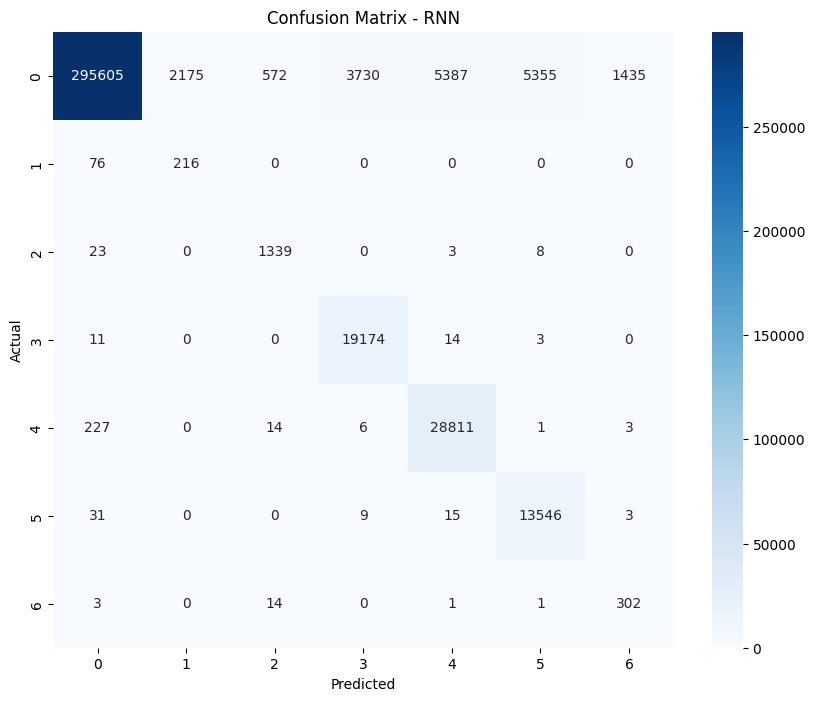

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

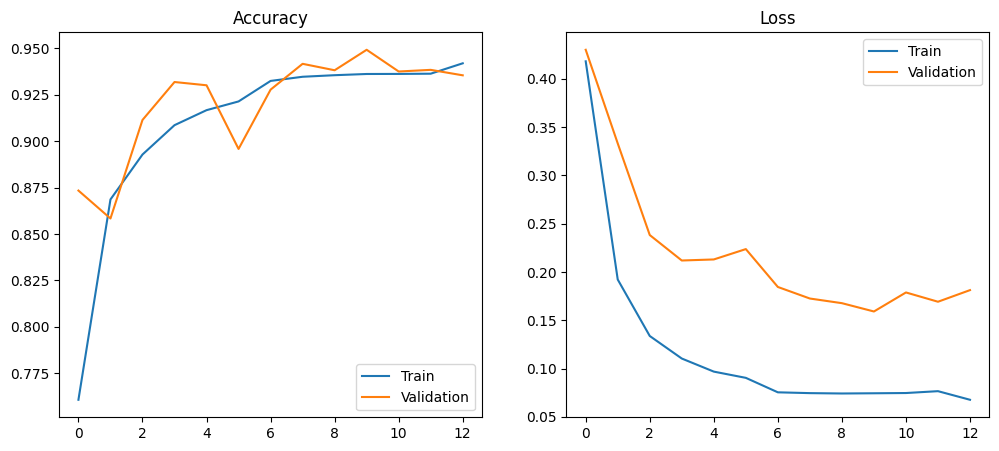

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [15]:
# Save in legacy HDF5 format
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm_model_fixed.h5")

# Save in native Keras format (recommended)
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm_model_fixed.keras")

print("Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.")

Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.
